# Weibull Reliability Analysis of Turbofan Engine Lifetimes (NASA C-MAPSS)

The XGBoost classifiers in this repo answer an **engine-level** question: *is this specific engine about to fail, given its sensor readings?* This notebook answers the **fleet-level** questions a reliability or maintenance-planning team asks:

* How long do these engines typically last, and how variable is that?
* Is failure driven by wear-out (risk rising with age) or random events?
* Do operating conditions or fault modes change lifetimes?
* When should age-based inspections start, and how much does condition monitoring add?

It also works through a pitfall that would silently bias the answers: the test engines are **censored** (observation stops before failure), but not in the way standard methods assume.

**Data:** run `python 01_fetch_data.py` first. Training engines run to failure (complete lifetimes); test engines stop before failure, with the true remaining life provided separately in `RUL_FD00x.txt`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import gamma
from lifelines import WeibullFitter, KaplanMeierFitter
from lifelines.statistics import logrank_test
from sklearn.metrics import roc_auc_score, mean_absolute_error

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
DATA = "data/raw"
DATASETS = {"FD001": "1 condition, 1 fault mode", "FD002": "6 conditions, 1 fault mode",
            "FD003": "1 condition, 2 fault modes", "FD004": "6 conditions, 2 fault modes"}

def read(kind, fd):
    df = pd.read_csv(f"{DATA}/{kind}_{fd}.txt", sep=r"\s+", header=None).iloc[:, :2]
    df.columns = ["unit", "cycle"]
    return df

train_life, test = {}, {}
for fd in DATASETS:
    train_life[fd] = read("train", fd).groupby("unit")["cycle"].max().to_numpy()
    observed = read("test", fd).groupby("unit")["cycle"].max().to_numpy()
    rul = pd.read_csv(f"{DATA}/RUL_{fd}.txt", header=None)[0].to_numpy()
    test[fd] = pd.DataFrame({"age": observed, "true_rul": rul, "true_life": observed + rul})

pd.DataFrame({fd: {"description": DATASETS[fd], "training engines (failed)": len(train_life[fd]),
                   "test engines (censored)": len(test[fd]), "shortest life": train_life[fd].min(),
                   "median life": int(np.median(train_life[fd])), "longest life": train_life[fd].max()}
              for fd in DATASETS}).T

,description,training engines (failed),test engines (censored),shortest life,median life,longest life
FD001,"1 condition, 1 fault mode",100,100,128,199,362
FD002,"6 conditions, 1 fault mode",260,259,128,199,378
FD003,"1 condition, 2 fault modes",100,100,145,220,525
FD004,"6 conditions, 2 fault modes",249,248,128,234,543


## 1. Lifetime distributions

Every training engine runs to failure, so these are complete lifetimes in operating cycles. Note that **no engine fails before cycle 128** (145 in FD003): there is a failure-free period, which matters in Section 6.

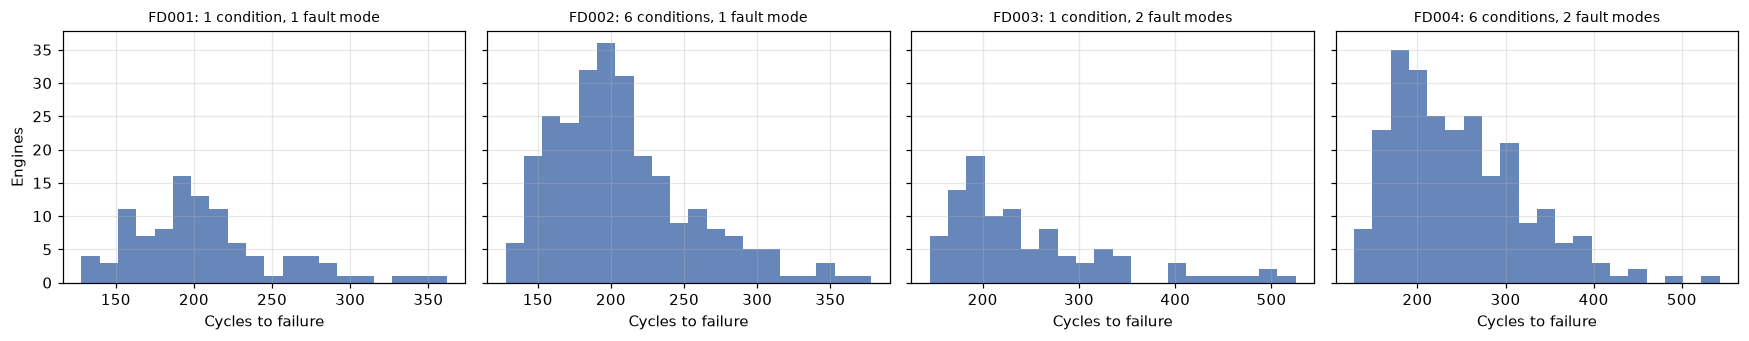

In [2]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.2), sharey=True)
for ax, fd in zip(axes, DATASETS):
    ax.hist(train_life[fd], bins=20, color="#4C72B0", alpha=0.85)
    ax.set_title(f"{fd}: {DATASETS[fd]}", fontsize=9)
    ax.set_xlabel("Cycles to failure")
axes[0].set_ylabel("Engines")
plt.tight_layout()

## 2. Two-parameter Weibull fits

$R(t) = \exp\left[-(t/\eta)^\beta\right]$, where **β (shape)** describes the failure pattern (β < 1 early failures, β ≈ 1 random, β > 1 wear-out) and **η (scale)** is the characteristic life, the age by which 63.2% of units have failed. **B10 life** is the age by which 10% have failed, a common basis for maintenance intervals. Fitted by maximum likelihood on the complete training lifetimes.

In [3]:
def fit_weibull(durations, observed=None):
    observed = np.ones_like(durations) if observed is None else observed
    w = WeibullFitter().fit(durations, observed)
    ci = w.summary[["coef lower 95%", "coef upper 95%"]]
    return {"beta": w.rho_, "beta 95% CI": f"{ci.loc['rho_'].iloc[0]:.2f}–{ci.loc['rho_'].iloc[1]:.2f}",
            "eta": w.lambda_, "eta 95% CI": f"{ci.loc['lambda_'].iloc[0]:.0f}–{ci.loc['lambda_'].iloc[1]:.0f}",
            "mean life": w.lambda_ * gamma(1 + 1 / w.rho_),
            "B1 life": w.lambda_ * (-np.log(0.99)) ** (1 / w.rho_),
            "B10 life": w.lambda_ * (-np.log(0.90)) ** (1 / w.rho_),
            "AIC": w.AIC_, "model": w}

fits = {fd: fit_weibull(train_life[fd]) for fd in DATASETS}
table = pd.DataFrame({fd: {k: v for k, v in f.items() if k != "model"} for fd, f in fits.items()}).T
table.style.format({"beta": "{:.2f}", "eta": "{:.0f}", "mean life": "{:.0f}", "B1 life": "{:.0f}",
                    "B10 life": "{:.0f}", "AIC": "{:.0f}"})

,beta,beta 95% CI,eta,eta 95% CI,mean life,B1 life,B10 life,AIC
FD001,4.41,3.80–5.01,225,214–236,205,79,135,1065
FD002,4.39,4.01–4.76,226,219–232,206,79,135,2769
FD003,2.93,2.53–3.33,277,257–297,247,58,128,1177
FD004,3.47,3.16–3.78,273,263–283,245,72,143,2854


**Reading the table:** β is well above 1 in every dataset, so these engines fail by **wear-out**: failure risk rises steeply with age, which is exactly the regime where preventive maintenance pays off. The two-fault-mode datasets (FD003, FD004) have longer characteristic lives but lower β, meaning lifetimes are **more spread out** and harder to plan around with a fixed age-based interval.

## 3. Goodness of fit: Weibull probability plots

On Weibull probability paper, a Weibull distribution plots as a straight line. Points use Bernard's median-rank approximation.

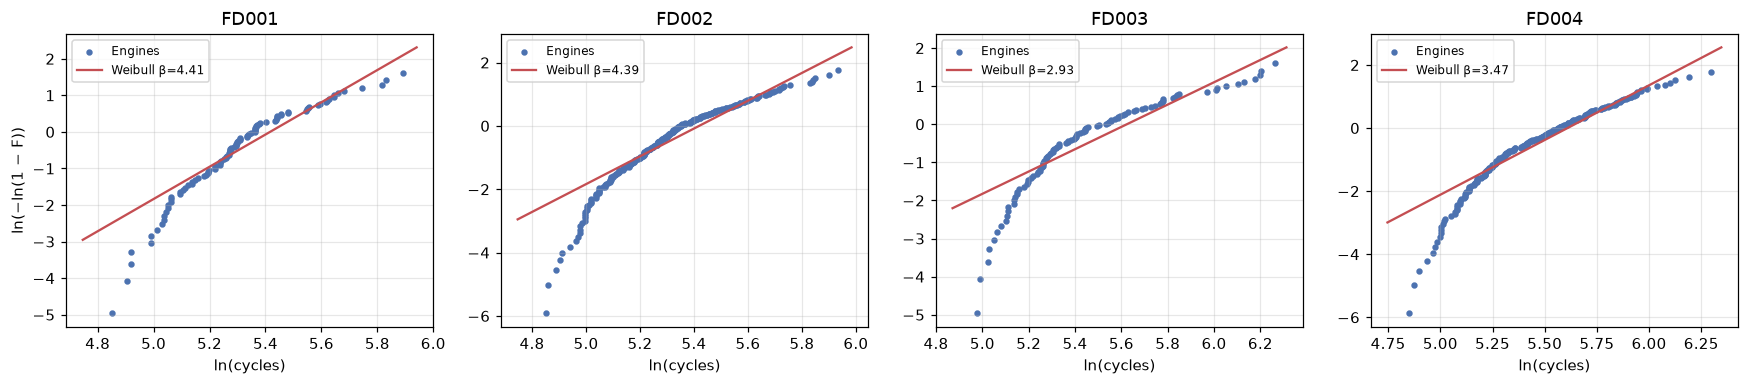

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.6))
for ax, fd in zip(axes, DATASETS):
    t = np.sort(train_life[fd]); n = len(t)
    F = (np.arange(1, n + 1) - 0.3) / (n + 0.4)               # Bernard's median ranks
    ax.scatter(np.log(t), np.log(-np.log(1 - F)), s=10, color="#4C72B0", label="Engines")
    b, e = fits[fd]["beta"], fits[fd]["eta"]
    grid = np.linspace(t.min() * 0.9, t.max() * 1.05, 100)
    ax.plot(np.log(grid), b * (np.log(grid) - np.log(e)), color="#C44E52", label=f"Weibull β={b:.2f}")
    ax.set_title(fd); ax.set_xlabel("ln(cycles)")
    ax.legend(fontsize=8)
axes[0].set_ylabel("ln(−ln(1 − F))")
plt.tight_layout()

The fit is good through the body of the distribution, but the lowest points bend away from the line: early failures are **rarer** than a two-parameter Weibull predicts. That curvature is the signature of a failure-free period, examined in Section 6.

## 4. Reliability and hazard curves

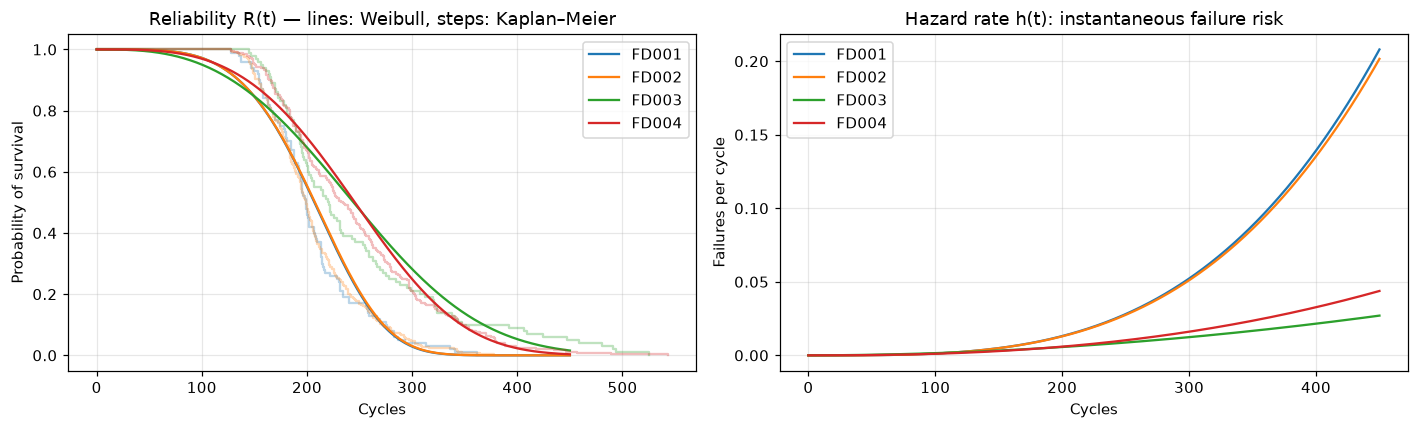

In [5]:
t = np.linspace(0, 450, 451)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
for fd in DATASETS:
    b, e = fits[fd]["beta"], fits[fd]["eta"]
    ax1.plot(t, np.exp(-(t / e) ** b), label=fd)
    ax2.plot(t, (b / e) * (t / e) ** (b - 1), label=fd)
    km = KaplanMeierFitter().fit(train_life[fd])
    ax1.step(km.timeline, km.survival_function_.iloc[:, 0], where="post", alpha=0.3, color=ax1.lines[-1].get_color())
ax1.set(title="Reliability R(t) — lines: Weibull, steps: Kaplan–Meier", xlabel="Cycles", ylabel="Probability of survival")
ax2.set(title="Hazard rate h(t): instantaneous failure risk", xlabel="Cycles", ylabel="Failures per cycle")
ax1.legend(); ax2.legend()
plt.tight_layout()

Through the main failure region the Weibull curves track the nonparametric Kaplan–Meier estimates (steps) closely. Early in life they don't: the two-parameter curves start declining around cycle 50, while no engine actually fails before cycle 128. That is the same failure-free period seen in the probability plots. The rising hazard curves are the wear-out signature: an engine at cycle 250 is about five times more likely to fail in the next cycle than one at cycle 150.

## 5. Do operating conditions or fault modes change lifetimes?

Log-rank tests compare lifetime distributions between datasets.

In [6]:
pairs = [("FD001", "FD002", "operating conditions (1 vs 6), one fault mode"),
         ("FD003", "FD004", "operating conditions (1 vs 6), two fault modes"),
         ("FD001", "FD003", "fault modes (1 vs 2), one condition"),
         ("FD002", "FD004", "fault modes (1 vs 2), six conditions")]
pd.DataFrame([{"comparison": f"{a} vs {b}", "varies": what,
               "median life": f"{np.median(train_life[a]):.0f} vs {np.median(train_life[b]):.0f}",
               "log-rank p-value": logrank_test(train_life[a], train_life[b]).p_value}
              for a, b, what in pairs]).style.format({"log-rank p-value": "{:.3g}"}).hide(axis="index")

comparison,varies,median life,log-rank p-value
FD001 vs FD002,"operating conditions (1 vs 6), one fault mode",199 vs 199,0.868
FD003 vs FD004,"operating conditions (1 vs 6), two fault modes",220 vs 234,0.729
FD001 vs FD003,"fault modes (1 vs 2), one condition",199 vs 220,3.83e-05
FD002 vs FD004,"fault modes (1 vs 2), six conditions",199 vs 234,1.01e-13


**Operating conditions do not change lifetimes** (no significant difference), but **fault modes do**: engines with two degradation modes (HPC and fan) live longer on average with more variability. For planning, that means two populations, not four:

In [7]:
populations = {"One fault mode (FD001+FD002)": np.r_[train_life["FD001"], train_life["FD002"]],
               "Two fault modes (FD003+FD004)": np.r_[train_life["FD003"], train_life["FD004"]]}
pop_fits = {name: fit_weibull(life) for name, life in populations.items()}
pd.DataFrame({n: {k: v for k, v in f.items() if k not in ("model", "AIC")} for n, f in pop_fits.items()}).T.style.format(
    {"beta": "{:.2f}", "eta": "{:.0f}", "mean life": "{:.0f}", "B1 life": "{:.0f}", "B10 life": "{:.0f}"})

,beta,beta 95% CI,eta,eta 95% CI,mean life,B1 life,B10 life
One fault mode (FD001+FD002),4.39,4.07–4.71,225,220–231,205,79,135
Two fault modes (FD003+FD004),3.27,3.02–3.51,274,265–283,246,67,138


## 6. Three-parameter Weibull: modeling the failure-free period

Adding a location parameter γ shifts the distribution so failure is impossible before γ: $R(t) = \exp\left[-((t-\gamma)/\eta)^\beta\right]$ for $t > \gamma$.

In [8]:
# Profile likelihood: for each candidate failure-free life γ below the first failure, fit β and η to (t − γ)
# and keep the γ with the highest likelihood. More stable than a direct 3-parameter optimization.
rows = []
for name, life in populations.items():
    best = None
    for g in np.arange(0, life.min() - 1, 1.0):
        c, _, scale = stats.weibull_min.fit(life - g, floc=0)
        ll = stats.weibull_min.logpdf(life - g, c, 0, scale).sum()
        if best is None or ll > best[0]:
            best = (ll, g, c, scale)
    ll3, g, c, scale = best
    rows.append({"population": name, "γ (failure-free life)": g, "β": c, "η (beyond γ)": scale,
                 "AIC 3-parameter": 2 * 3 - 2 * ll3, "AIC 2-parameter": pop_fits[name]["AIC"]})
pd.DataFrame(rows).set_index("population").style.format("{:.1f}")

,γ (failure-free life),β,η (beyond γ),AIC 3-parameter,AIC 2-parameter
population,,,,,
One fault mode (FD001+FD002),126.0,1.8,90.7,3727.4,3830.2
Two fault modes (FD003+FD004),126.0,1.6,134.9,3932.7,4032.9


The three-parameter model fits much better (AIC about 100 points lower for both populations). Its γ estimate lands just below the shortest observed life, which is typical for three-parameter maximum likelihood, so read it as "**no failures before roughly 125 cycles**" rather than a precise value. With that failure-free period accounted for, β drops from 3–4.4 to about 1.6–1.8: once engines start failing, the wear-out phase is more gradual than the two-parameter model suggests, so failure ages after cycle 125 are spread widely. That supports a low-inspection window early in life followed by condition-based monitoring.

## 7. The censoring trap

Test engines stop before failure. The textbook approach treats each as **right-censored**: "survived at least this long." Maximum likelihood handles that correctly *if censoring is independent of lifetime*. Here we can check, because NASA provides each test engine's true remaining life.

In [9]:
rows = []
for fd in DATASETS:
    life, tst = train_life[fd], test[fd]
    naive = fit_weibull(np.r_[life, tst["age"]], np.r_[np.ones(len(life)), np.zeros(len(tst))])
    truth = fit_weibull(np.r_[life, tst["true_life"]])
    r, p = stats.pearsonr(tst["age"], tst["true_life"])
    rows.append({"dataset": fd, "η with test engines censored": naive["eta"], "η with true lifetimes": truth["eta"],
                 "bias in η": naive["eta"] / truth["eta"] - 1,
                 "corr(censoring age, true life)": r, "share of life observed": (tst["age"] / tst["true_life"]).mean()})
pd.DataFrame(rows).set_index("dataset").style.format({"η with test engines censored": "{:.0f}", "η with true lifetimes": "{:.0f}",
    "bias in η": "{:+.1%}", "corr(censoring age, true life)": "{:.2f}", "share of life observed": "{:.0%}"})

,η with test engines censored,η with true lifetimes,bias in η,"corr(censoring age, true life)",share of life observed
dataset,,,,,
FD001,237,225,+5.3%,0.65,63%
FD002,240,229,+5.1%,0.56,61%
FD003,313,273,+14.7%,0.88,66%
FD004,305,278,+9.8%,0.81,64%


Treating test engines as ordinary censored data **overstates characteristic life by 5–15% in every dataset**. The cause is visible in the last two columns: each test trajectory was cut off at a random *fraction of that engine's own life* (on average about 60–65%), so long-lived engines are observed longer. Censoring time is strongly correlated with lifetime, which violates the independence assumption.

A quick simulation with a known Weibull confirms the mechanism:

In [10]:
rng = np.random.default_rng(0)
beta_true, eta_true, n, reps = 4.5, 225, 200, 200
bias = {"independent censoring": [], "censoring proportional to own life": []}
for _ in range(reps):
    failed = eta_true * rng.weibull(beta_true, n)
    T = eta_true * rng.weibull(beta_true, n)
    schemes = {"independent censoring": eta_true * rng.weibull(beta_true, n) * rng.uniform(0.1, 0.97, n),
               "censoring proportional to own life": T * rng.uniform(0.1, 0.97, n)}
    for name, C in schemes.items():
        dur, obs = np.minimum(T, C), (T <= C).astype(int)
        w = WeibullFitter().fit(np.r_[failed, dur], np.r_[np.ones(n), obs])
        bias[name].append(w.lambda_ / eta_true - 1)
pd.Series({k: f"{np.mean(v):+.1%}" for k, v in bias.items()}, name="mean bias in η (200 simulations)").to_frame()

,mean bias in η (200 simulations)
independent censoring,-0.1%
censoring proportional to own life,+3.8%


Independent censoring gives an unbiased estimate; censoring tied to each unit's own life inflates η. **Lesson for real fleets:** when units leave observation for reasons related to their condition (removed early because they looked degraded, or monitored longer because they looked healthy), standard reliability estimates are biased. Check how observation ends before trusting the fit.

## 8. Fleet-level age vs. sensor-based condition monitoring

Weibull analysis predicts failure from **age alone**. For each test engine we can compute the conditional probability of failing within the next 50 cycles given it has survived to its current age, and compare with what actually happened.

In [11]:
def conditional_failure_prob(age, horizon, beta, eta):
    return 1 - np.exp(-(((age + horizon) / eta) ** beta - (age / eta) ** beta))

def mean_residual_life(age, beta, eta, grid=np.arange(0, 600)):
    s_age = np.exp(-(age / eta) ** beta)
    return np.array([np.exp(-((a + grid) / eta) ** beta).sum() / s for a, s in zip(age, s_age)])

rows = []
for fd in DATASETS:
    b, e = fits[fd]["beta"], fits[fd]["eta"]
    tst = test[fd]
    p50 = conditional_failure_prob(tst["age"].to_numpy(), 50, b, e)
    mrl = mean_residual_life(tst["age"].to_numpy(), b, e)
    rows.append({"dataset": fd, "AUC: fails within 50 cycles (age only)": roc_auc_score(tst["true_rul"] <= 50, p50),
                 "remaining-life MAE (cycles, age only)": mean_absolute_error(tst["true_rul"], mrl)})
pd.DataFrame(rows).set_index("dataset").style.format("{:.2f}")

,AUC: fails within 50 cycles (age only),"remaining-life MAE (cycles, age only)"
dataset,,
FD001,0.81,32.51
FD002,0.86,33.55
FD003,0.80,55.30
FD004,0.72,51.01


Age alone separates engines near failure only moderately, and remaining-life estimates are off by dozens of cycles, because engines of the same age can be in very different condition. The sensor-based classifiers in this repo (see `results.md`) catch about **92% of engines within 50 cycles of failure** on held-out engines. The two approaches answer different questions:

* **Weibull (fleet level):** how many failures to expect, spare-parts and shop capacity planning, and the age at which monitoring must be in place.
* **Sensor models (engine level):** which specific engine to pull, and when.

## 9. Maintenance implications

In [12]:
rows = []
for name, f in pop_fits.items():
    b, e = f["beta"], f["eta"]
    ages = np.arange(0, 400)
    risk = conditional_failure_prob(ages, 50, b, e)
    rows.append({"population": name, "B1 life": f["B1 life"], "B10 life": f["B10 life"],
                 "age when 50-cycle failure risk exceeds 10%": ages[np.argmax(risk > 0.10)],
                 "age when 50-cycle failure risk exceeds 50%": ages[np.argmax(risk > 0.50)]})
pd.DataFrame(rows).set_index("population").style.format("{:.0f}")

,B1 life,B10 life,age when 50-cycle failure risk exceeds 10%,age when 50-cycle failure risk exceeds 50%
population,,,,
One fault mode (FD001+FD002),79,135,90,178
Two fault modes (FD003+FD004),67,138,102,268


**Recommendations for a fleet like this:**

1. **Condition monitoring is the primary control.** With strong wear-out (β > 3) but wide spread between engines, a fixed replacement age either wastes life or misses failures. Sensor-based alerts should drive individual removals.
2. **Use Weibull to set the age window for monitoring.** The two-parameter thresholds above (about 90–100 cycles) are conservative, because that model assigns some risk to ages where no engine has ever failed. The three-parameter fit shows no failures before roughly 125 cycles, so sensor monitoring should be fully in place by then, with alert sensitivity increasing as engines approach their B10 life (about 135–140 cycles).
3. **Plan the two fault-mode populations separately.** Engines exposed to two degradation modes last longer on average but are less predictable; a single fleet-wide interval would be too early for some and too late for others.
4. **Audit how units leave observation before fitting.** Censoring tied to condition biased characteristic life upward by 5–15% here, which would translate directly into intervals set too long.